# 机器学习与深度学习知识分享

**目标读者**：有一定编程基础的程序员，了解 Python，但不一定有 ML/DL 背景。

**内容风格**：每章先讲清楚核心概念与直觉，再配合 Python 代码示例加深理解，不从零手写底层实现。

---

## 目录

| 章节 | 内容 |
|------|------|
| **1.1 线性代数** | 向量、矩阵运算、特征值分解、SVD |
| **1.2 概率与统计** | 贝叶斯定理、常见分布、最大似然估计 |
| **1.3 微积分与优化** | 偏导数、梯度、链式法则、梯度下降 |

---

## 环境准备

### 第一步：安装 Python 3.11

推荐使用 **Python 3.11**（稳定性最佳，主流 ML 库已全面适配）。

从 [python.org](https://www.python.org/downloads/release/python-3119/) 下载 Python 3.11 安装包，安装时勾选 **"Add to PATH"**。安装完成后可通过 Windows Python Launcher 按版本调用：

```bash
py -3.11 --version   # 确认 3.11 已安装
```

### 第二步：创建虚拟环境

使用 `py -3.11` 确保虚拟环境内的 Python 版本固定为 3.11：

```bash
# 创建虚拟环境（固定 Python 3.11）
py -3.11 -m venv .venv

# 激活（Windows）
.venv\Scripts\activate

# 激活后确认版本
python --version    # 应输出 Python 3.11.x
```

> 如果使用 **Miniconda**，等效命令为：
> ```bash
> conda create -n ml_dl python=3.11
> conda activate ml_dl
> ```

### 第三步：安装依赖

```bash
pip install -r requirements.txt
pip install modelscope   # 用于从魔搭社区下载预训练模型
```

> **GPU 用户**：PyTorch 默认安装 CPU 版。如需 GPU（CUDA）支持，请先卸载再按照 [pytorch.org](https://pytorch.org/get-started/locally/) 选择对应 CUDA 版本安装。

### 第四步：下载预训练模型（第二部分需要）

第二部分聚类算法用到 `text2vec-base-chinese`（768 维中文语义向量模型，约 400 MB）。模型通过 **ModelScope（魔搭社区）** 下载，无需注册，国内网络直接访问：

```python
from modelscope import snapshot_download
snapshot_download('Jerry0/text2vec-base-chinese')
```

> 也可以在 Notebook 中直接运行上面两行，首次执行时自动下载并缓存到本地，后续运行直接复用缓存。

### 第五步：注册 Jupyter kernel

```bash
python -m ipykernel install --user --name ml_dl --display-name "Python 3.11 (ml_dl)"
```

In [1]:
# 运行此 cell 验证所有依赖是否安装正确
import importlib, sys

required = {
    'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 'sklearn': 'scikit-learn', 'scipy': 'scipy',
    'torch': 'torch', 'torchvision': 'torchvision',
    'xgboost': 'xgboost', 'transformers': 'transformers', 'datasets': 'datasets',
}

all_ok = True
for module, pkg in required.items():
    try:
        m = importlib.import_module(module)
        print(f'  OK  {pkg:<20} {getattr(m, "__version__", "n/a")}')
    except ImportError:
        print(f'  MISSING  {pkg}  →  pip install {pkg}')
        all_ok = False

if all_ok:
    import torch
    print(f'\nPython: {sys.version.split()[0]}')
    print(f'CUDA available: {torch.cuda.is_available()}')

  OK  numpy                2.4.6


  OK  pandas               3.0.3


  OK  matplotlib           3.10.9


  OK  seaborn              0.13.2


  OK  scikit-learn         1.8.0
  OK  scipy                1.17.1


  OK  torch                2.12.0+cpu


  OK  torchvision          0.27.0+cpu
  OK  xgboost              3.2.0


  OK  transformers         5.9.0


  OK  datasets             4.8.5

Python: 3.14.5
CUDA available: False


In [2]:
# 修复 matplotlib 中文字体（Windows 微软雅黑）
import matplotlib
matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False  # 负号正常显示
print('字体设置完成:', matplotlib.rcParams['font.family'])


字体设置完成: ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']


---

# 第一部分：数学基础

对于程序员来说，ML 里的数学不需要从公式推导入手——重要的是理解**每个概念在计算中对应什么操作**，以及**为什么 ML 算法需要它**。本部分用 NumPy 把数学操作跑起来，建立直觉。

## 1.1 线性代数

线性代数是 ML 的语言。数据集是矩阵，神经网络每一层是矩阵乘法，PCA 是特征值分解——理解线性代数就是理解数据如何流动和变换。

### 向量（Vector）

向量是一个有序数字列表，代表 n 维空间中的一个点，或从原点出发有方向和长度的箭头。

在 ML 中：一个样本的所有特征 → 一个向量；模型的权重参数 → 一个向量；词嵌入 → 一个高维向量。

**点积（Dot Product）** 衡量两个向量方向的接近程度，是推荐系统、余弦相似度、注意力机制的核心：

$$\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i = |\mathbf{a}||\mathbf{b}|\cos\theta$$

### 矩阵（Matrix）

矩阵是二维数组。在 ML 中：数据集 → `(n_samples, n_features)` 矩阵；神经网络权重层 → 矩阵。

**矩阵乘法** `Y = XW` 是线性变换的核心，把数据从一个空间映射到另一个空间。神经网络的每一层都在做这件事（加上激活函数引入非线性）。

### 特征值与特征向量

对矩阵 A，若 `Av = λv`，则 v 是特征向量，λ 是对应的特征值。

直觉：特征向量是矩阵变换中**不改变方向**的轴，特征值是它被拉伸的倍数。PCA 找的正是数据协方差矩阵的特征向量——数据方差最大的方向。

### SVD（奇异值分解）

任意矩阵都可以分解为 `A = UΣVᵀ`，三个矩阵各有含义：

| 矩阵 | 形状 | 含义 |
|------|------|------|
| **U** | m×m | 每个样本（行）在"潜在维度"上的坐标 |
| **Σ** | 对角 | 奇异值 σ₁ ≥ σ₂ ≥ … ≥ 0，越大说明该方向信息越重要 |
| **Vᵀ** | n×n | 每个特征（列）与"潜在维度"的关联强度 |

**直觉**：SVD 能从原始数据里自动挖掘隐藏的"主题结构"——文章的话题、用户的偏好类型——不需要任何标签。

**低秩近似**：只保留前 k 个奇异值（其余置零），用更少的信息近似原矩阵。前 2~3 个奇异值通常已涵盖 80~90% 的信息量。

下面用 **20 篇 AI 文章 × 10 个高频词汇** 的词频矩阵来具体演示这一点。

### SVD 实战：用词频矩阵给文章自动分类

**场景**：有 20 篇 AI 领域文章，统计了 10 个高频词汇在每篇文章中出现的次数，构成一个 **20×10 的词频矩阵**。

直接看这个矩阵很难发现规律——SVD 把它压缩到 2 维，让同类文章**自动聚集在一起**，完全不需要标签。

**分解过程**：`A (20×10) = U (20×10) · Σ (10) · Vᵀ (10×10)`

- 取 U 的前 2 列，乘以对应奇异值 → 每篇文章在 2D 空间的坐标
- 奇异值越大，该"潜在主题"方向携带的信息越多

词频矩阵 A (20×10)，前5行：
         模型    训练    数据  神经网络    文本    图像   词向量    奖励    策略    分类
监督学习入门       10     6     9     4     1     1     2     1     2     7
决策树原理        10     8     7     4     2     1     1     1     1     6
随机森林调参        8     6     8     3     1     1     0     2     2     7
梯度提升方法        9     8     8     3     3     2     2     2     0     7
正则化技术         8     8     9     2     1     3     1     0     1     6
  ...

SVD 分解结果：A = U · Σ · Vt

── U  (20, 10)  每篇文章在各潜在主题方向上的坐标 ──
   （行=文章，列=潜在主题维度，共10个维度）
              主题 1  主题 2  主题 3  主题 4  主题 5  主题 6  主题 7  主题 8  主题 9  主题10
  监督学习入门       -0.25    0.08   -0.00   -0.39   -0.40    0.18   -0.20   -0.06    0.14    0.20
  决策树原理        -0.24    0.09    0.03   -0.37    0.18    0.38    0.07   -0.28   -0.13   -0.32
  随机森林调参       -0.22    0.03    0.02   -0.37   -0.14   -0.04   -0.09    0.44   -0.18    0.06
  梯度提升方法       -0.25    0.13    0.00   -0.32    0.36   -0.03    0.03    0.16    0.15   -0.07
  正则化技术        -0.23    0

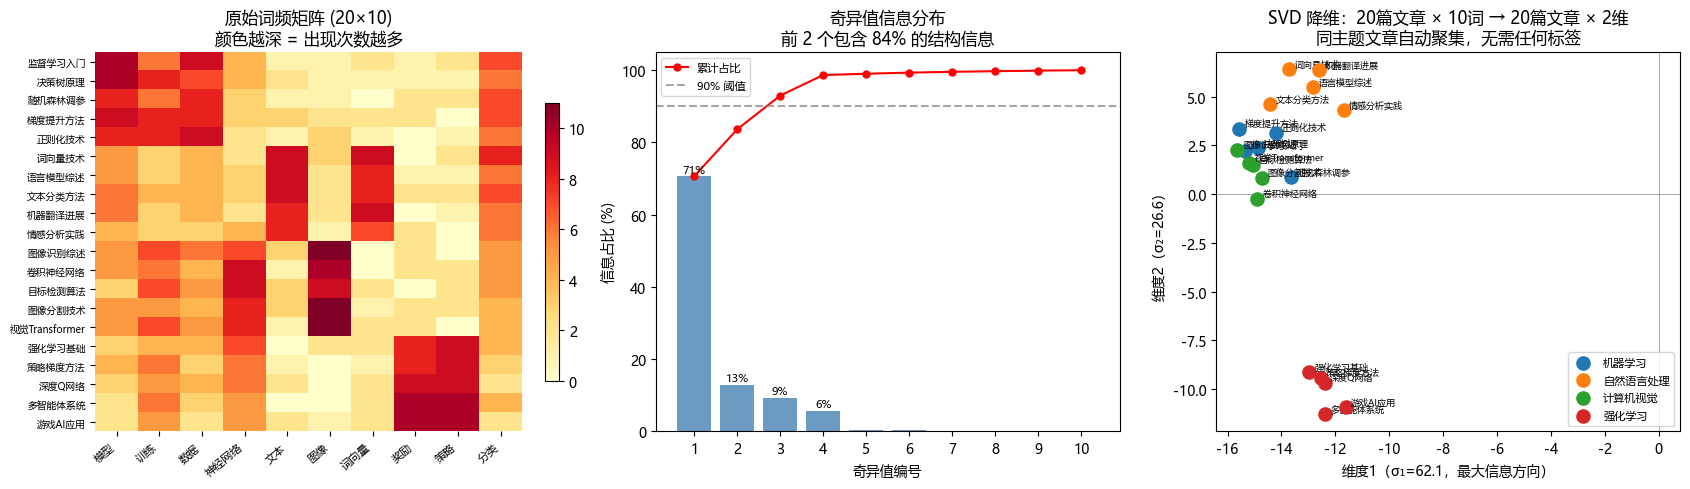

=== 降维结果解读 ===

原始矩阵：(20, 10)  →  降维后：(20, 2)
每篇文章从 10 个词频数字，变成 2 个坐标数字。

【维度数 ≠ 类别数】
  k=2 表示用 2 个坐标轴描述每篇文章，不是说分成 2 类。
  数据里有几个天然的簇，取决于文章的词频模式，与 k 无关。
  本例中数据本身有 4 个主题，所以 2D 图里出现 4 个簇。

【两个维度的含义】
  维度1（σ1=62.1）：正方向词 []
           负方向词 [训练(-0.40), 模型(-0.40), 分类(-0.38)]
  维度2（σ2=26.6）：正方向词 [文本(+0.31), 词向量(+0.22), 模型(+0.20)]
           负方向词 [策略(-0.60), 奖励(-0.58), 神经网络(-0.19)]

【如何投影新文章】
  new_article = np.array([5,3,4,1,0,8,0,0,0,3])  # 新文章的10个词频
  new_coords  = new_article @ Vt[:2].T             # 直接得到2D坐标，不需要重新做SVD
  结果：[-8.38  2.84]  → 与 CV 类文章坐标接近（偏图像/神经网络）


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. 数据定义 ───────────────────────────────────────────────
words = ["模型", "训练", "数据", "神经网络", "文本", "图像", "词向量", "奖励", "策略", "分类"]

articles = [
    # 机器学习（ML）
    "监督学习入门", "决策树原理", "随机森林调参", "梯度提升方法", "正则化技术",
    # 自然语言处理（NLP）
    "词向量技术",   "语言模型综述", "文本分类方法", "机器翻译进展", "情感分析实践",
    # 计算机视觉（CV）
    "图像识别综述", "卷积神经网络", "目标检测算法", "图像分割技术", "视觉Transformer",
    # 强化学习（RL）
    "强化学习基础", "策略梯度方法", "深度Q网络",   "多智能体系统", "游戏AI应用",
]
topic_labels = ['机器学习']*5 + ['自然语言处理']*5 + ['计算机视觉']*5 + ['强化学习']*5
colors       = ['C0']*5 + ['C1']*5 + ['C2']*5 + ['C3']*5

# ── 2. 构造 20×10 词频矩阵 ────────────────────────────────────
#              模型  训练  数据  神经网络  文本  图像  词向量  奖励  策略  分类
base = np.array([
    [8,  6,  7,   2,   1,   1,   0,   0,   0,  5],  # ML
    [4,  3,  3,   2,   8,   1,   7,   0,   0,  6],  # NLP
    [3,  5,  4,   7,   1,   9,   0,   0,   0,  4],  # CV
    [2,  4,  2,   5,   0,   0,   0,   8,   9,  2],  # RL
], dtype=float)

np.random.seed(42)
A = np.vstack([base[i // 5] + np.random.randint(0, 3, size=10) for i in range(20)])

print("词频矩阵 A (20×10)，前5行：")
print("       " + "  ".join(f"{w:>4}" for w in words))
for i in range(5):
    print(f"{articles[i]:<10} " + "  ".join(f"{int(v):>4}" for v in A[i]))
print("  ...")

# ── 3. SVD 分解 ───────────────────────────────────────────────
U, S, Vt = np.linalg.svd(A, full_matrices=False)
# U: (20,10)  S: (10,)  Vt: (10,10)

np.set_printoptions(precision=2, suppress=True, linewidth=120)

print("\n" + "="*60)
print("SVD 分解结果：A = U · Σ · Vt")
print("="*60)

print(f"\n── U  {U.shape}  每篇文章在各潜在主题方向上的坐标 ──")
print(f"   （行=文章，列=潜在主题维度，共{U.shape[1]}个维度）")
header = "            " + "".join(f"  主题{j+1:>2}" for j in range(U.shape[1]))
print(header)
for i in range(20):
    print(f"  {articles[i]:<10}" + "".join(f"  {v:>6.2f}" for v in U[i]))

print(f"\n── Σ  {S.shape}  各潜在主题的重要程度（奇异值，从大到小） ──")
for i, val in enumerate(S):
    bar = '█' * int(val / S[0] * 20)
    pct = val**2 / (S**2).sum()
    print(f"  σ{i+1} = {val:>6.2f}  {bar:<20}  占信息量 {pct:.1%}")

print(f"\n── Vt  {Vt.shape}  每个潜在主题由哪些词构成 ──")
print(f"   （行=潜在主题维度，列=词汇，正值越大=该词越能代表该主题方向）")
print("         " + "".join(f"  {w:>4}" for w in words))
for j in range(Vt.shape[0]):
    print(f"  主题{j+1:>2}  " + "".join(f"  {v:>4.2f}" for v in Vt[j]))

# ── 4. 降维：原始矩阵投影到 Vt 前2行 ─────────────────────────
# Vt[:2] 是前2个"主题方向向量"，形状 (2, 10)
# A (20,10) @ Vt[:2].T (10,2) = coords_2d (20,2)
# 含义：每篇文章的10维词频，在两个最重要的主题方向上各自的投影值
coords_2d = A @ Vt[:2, :].T   # shape: (20, 2)

# ── 5. 可视化 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 左：原始词频热力图
im = axes[0].imshow(A, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(words, rotation=40, ha='right', fontsize=8)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(articles, fontsize=7)
for spine in axes[0].spines.values():
    spine.set_visible(False)
plt.colorbar(im, ax=axes[0], fraction=0.03)
axes[0].set_title('原始词频矩阵 (20×10)\n颜色越深 = 出现次数越多')

# 中：奇异值衰减图
explained  = S**2 / (S**2).sum()
cumulative = np.cumsum(explained)
axes[1].bar(range(1, 11), explained * 100, color='steelblue', alpha=0.8)
axes[1].plot(range(1, 11), cumulative * 100, 'ro-', ms=5, label='累计占比')
axes[1].axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% 阈值')
axes[1].set_xlabel('奇异值编号')
axes[1].set_ylabel('信息占比 (%)')
axes[1].set_title(f'奇异值信息分布\n前 2 个包含 {cumulative[1]:.0%} 的结构信息')
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, 11))
for i, v in enumerate(explained[:4]):
    axes[1].text(i + 1, v * 100 + 1, f'{v:.0%}', ha='center', fontsize=8)

# 右：2D 散点图
seen = set()
for i, (x, y) in enumerate(coords_2d):
    topic = topic_labels[i]
    axes[2].scatter(x, y, color=colors[i], s=90,
                    label=topic if topic not in seen else None, zorder=3)
    seen.add(topic)
    axes[2].annotate(articles[i], (x, y), fontsize=6.5,
                     xytext=(4, 2), textcoords='offset points')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].axvline(0, color='gray', lw=0.5)
axes[2].set_xlabel(f'维度1（σ₁={S[0]:.1f}，最大信息方向）')
axes[2].set_ylabel(f'维度2（σ₂={S[1]:.1f}）')
axes[2].set_title('SVD 降维：20篇文章 × 10词 → 20篇文章 × 2维\n同主题文章自动聚集，无需任何标签')
axes[2].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# ── 6. 结果解读 ───────────────────────────────────────────────
print("=== 降维结果解读 ===\n")
print(f"原始矩阵：{A.shape}  →  降维后：{coords_2d.shape}")
print(f"每篇文章从 10 个词频数字，变成 2 个坐标数字。\n")

print("【维度数 ≠ 类别数】")
print(f"  k=2 表示用 2 个坐标轴描述每篇文章，不是说分成 2 类。")
print(f"  数据里有几个天然的簇，取决于文章的词频模式，与 k 无关。")
print(f"  本例中数据本身有 4 个主题，所以 2D 图里出现 4 个簇。\n")

print("【两个维度的含义】")
for dim in range(2):
    row = Vt[dim]
    pos = sorted([(w, v) for w, v in zip(words, row) if v > 0.1], key=lambda x: -x[1])
    neg = sorted([(w, v) for w, v in zip(words, row) if v < -0.1], key=lambda x: x[1])
    pos_str = ", ".join(f"{w}(+{v:.2f})" for w, v in pos[:3])
    neg_str = ", ".join(f"{w}({v:.2f})" for w, v in neg[:3])
    print(f"  维度{dim+1}（σ{dim+1}={S[dim]:.1f}）：正方向词 [{pos_str}]")
    if neg_str:
        print(f"           负方向词 [{neg_str}]")

print()
print("【如何投影新文章】")
print("  new_article = np.array([5,3,4,1,0,8,0,0,0,3])  # 新文章的10个词频")
print("  new_coords  = new_article @ Vt[:2].T             # 直接得到2D坐标，不需要重新做SVD")
new_article = np.array([5, 3, 4, 1, 0, 8, 0, 0, 0, 3], dtype=float)
new_coords  = new_article @ Vt[:2].T
print(f"  结果：{new_coords.round(2)}  → 与 CV 类文章坐标接近（偏图像/神经网络）")

## 1.2 概率与统计

ML 模型本质上是在从数据中**学习概率分布**。分类模型输出概率，损失函数背后是似然，正则化对应先验——概率论贯穿整个 ML。

### 概率分布

描述随机变量取各个值的可能性。ML 中最常见的分布：

| 分布 | 典型用途 |
|------|----------|
| **正态分布** N(μ, σ²) | 权重初始化、误差建模 |
| **伯努利分布** Bernoulli(p) | 二分类输出（0/1） |
| **多项分布** Categorical | 多分类（softmax 的概率解释） |

**为什么正态分布无处不在？** 中心极限定理（CLT）：大量独立随机变量之和趋近于正态分布，无论原始分布形状如何。

### 期望与方差

- **期望 E[X]**：随机变量的加权平均（重心）
- **方差 Var[X]**：偏离期望的平均平方距离，衡量分散程度
- **标准差 σ**：方差的平方根，与原变量同单位，更直观

### 贝叶斯定理

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

- **P(A)**：先验——观测 B 之前对 A 的信念
- **P(A|B)**：后验——观测 B 之后对 A 的更新信念
- **P(B|A)**：似然——假设 A 成立时，B 出现的概率

直觉：「用新证据更新旧信念」。垃圾邮件过滤、医疗诊断都用这个逻辑。

### 最大似然估计（MLE）

给定数据，找到让「数据出现概率最大」的参数。这是大多数 ML 训练的本质：
- 线性回归最小化 MSE ↔ 假设误差正态分布的 MLE
- 逻辑回归最小化交叉熵 ↔ 伯努利分布的 MLE

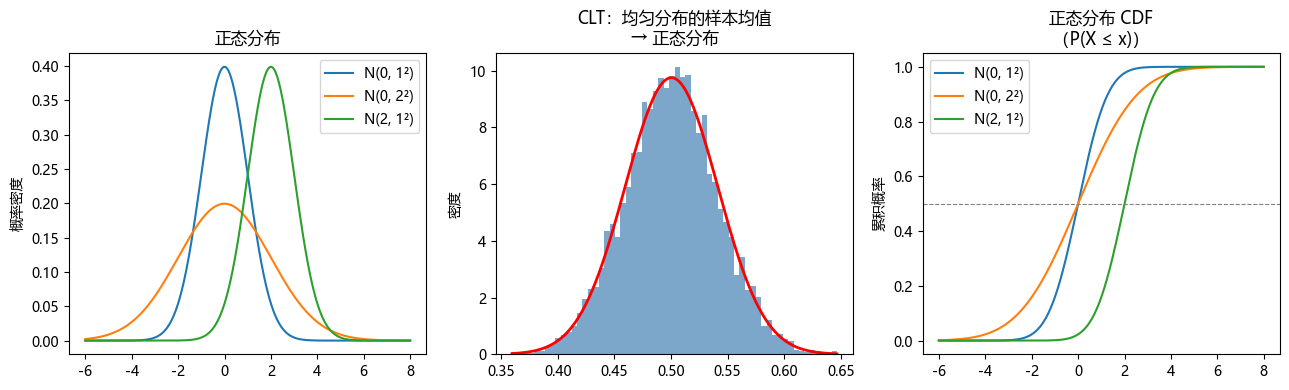

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 常见分布可视化 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# 正态分布：不同均值和标准差
x = np.linspace(-6, 8, 400)
for mu, sigma, c in [(0, 1, 'C0'), (0, 2, 'C1'), (2, 1, 'C2')]:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma),
                 label=f'N({mu}, {sigma}²)', color=c)
axes[0].set_title('正态分布')
axes[0].legend()
axes[0].set_ylabel('概率密度')

# 中心极限定理：均匀分布的样本均值 → 正态分布
np.random.seed(42)
sample_means = [np.mean(np.random.uniform(0, 1, 50)) for _ in range(5000)]
mu_h, sig_h = np.mean(sample_means), np.std(sample_means)
axes[1].hist(sample_means, bins=60, density=True, alpha=0.7, color='steelblue')
x_fit = np.linspace(min(sample_means), max(sample_means), 200)
axes[1].plot(x_fit, stats.norm.pdf(x_fit, mu_h, sig_h), 'r-', lw=2)
axes[1].set_title('CLT：均匀分布的样本均值\n→ 正态分布')
axes[1].set_ylabel('密度')

# 不同参数的正态分布的累积分布函数 (CDF)
for mu, sigma, c in [(0, 1, 'C0'), (0, 2, 'C1'), (2, 1, 'C2')]:
    axes[2].plot(x, stats.norm.cdf(x, mu, sigma),
                 label=f'N({mu}, {sigma}²)', color=c)
axes[2].set_title('正态分布 CDF\n（P(X ≤ x)）')
axes[2].legend()
axes[2].set_ylabel('累积概率')
axes[2].axhline(0.5, color='gray', lw=0.8, linestyle='--')

plt.tight_layout()
plt.show()

=== 贝叶斯定理：疾病检测 ===
患病率（先验）          P(sick)      = 1%
灵敏度                 P(+ | sick)  = 99%
假阳性率               P(+ | healthy) = 5%
检测阳性的总概率        P(+)         = 5.940%

阳性 → 真的患病（后验）P(sick | +)  = 16.67%

直觉：即使检测很准，因为患病率极低，大多数阳性结果仍是假阳性。

=== MLE：用数据估计正态分布参数 ===
真实参数:  μ = 5.0,    σ = 2.0
MLE 估计:  μ = 4.949,  σ = 1.996


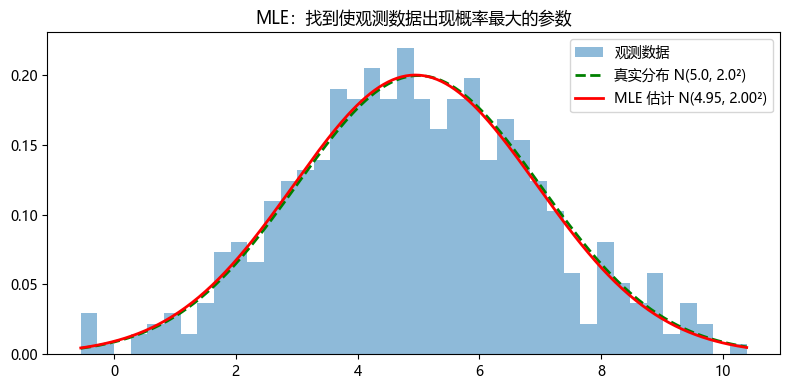

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 贝叶斯定理：疾病检测示例 ─────────────────────────────────
# 问题：某病发病率 1%，检测灵敏度 99%，特异度 95%
# 检测阳性，真的患病的概率是多少？
P_sick = 0.01              # 先验：患病率
P_pos_given_sick = 0.99    # 灵敏度：患病时检测阳性
P_pos_given_healthy = 0.05 # 1 - 特异度：健康时检测阳性（假阳性）

P_pos = P_pos_given_sick * P_sick + P_pos_given_healthy * (1 - P_sick)
P_sick_given_pos = (P_pos_given_sick * P_sick) / P_pos

print('=== 贝叶斯定理：疾病检测 ===')
print(f'患病率（先验）          P(sick)      = {P_sick:.0%}')
print(f'灵敏度                 P(+ | sick)  = {P_pos_given_sick:.0%}')
print(f'假阳性率               P(+ | healthy) = {P_pos_given_healthy:.0%}')
print(f'检测阳性的总概率        P(+)         = {P_pos:.3%}')
print(f'\n阳性 → 真的患病（后验）P(sick | +)  = {P_sick_given_pos:.2%}')
print('\n直觉：即使检测很准，因为患病率极低，大多数阳性结果仍是假阳性。')

# ── 最大似然估计（MLE）────────────────────────────────────────
print('\n=== MLE：用数据估计正态分布参数 ===')
np.random.seed(0)
true_mu, true_sigma = 5.0, 2.0
data = np.random.normal(true_mu, true_sigma, 500)

# MLE 解析解：均值和标准差的 MLE 就是样本均值和样本标准差
mle_mu    = np.mean(data)
mle_sigma = np.std(data)  # MLE 用 1/N（有偏），估计总体用 1/(N-1)

print(f'真实参数:  μ = {true_mu},    σ = {true_sigma}')
print(f'MLE 估计:  μ = {mle_mu:.3f},  σ = {mle_sigma:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=40, density=True, alpha=0.5, label='观测数据')
x = np.linspace(data.min(), data.max(), 300)
ax.plot(x, stats.norm.pdf(x, true_mu, true_sigma),
        'g--', lw=2, label=f'真实分布 N({true_mu}, {true_sigma}²)')
ax.plot(x, stats.norm.pdf(x, mle_mu, mle_sigma),
        'r-', lw=2, label=f'MLE 估计 N({mle_mu:.2f}, {mle_sigma:.2f}²)')
ax.set_title('MLE：找到使观测数据出现概率最大的参数')
ax.legend()
plt.tight_layout()
plt.show()

## 1.3 微积分与优化

训练 ML 模型 = 找到让损失函数最小的参数，这是一个优化问题。梯度下降是最核心的求解方法，背后的数学是微积分。

### 导数与偏导数

**导数** f'(x)：函数在 x 处的斜率，即 x 微小变化时 f(x) 变化多少。

对多变量函数 f(x₁, x₂, ..., xₙ)：
- **偏导数** ∂f/∂xᵢ：固定其他变量，只对 xᵢ 求导
- **梯度** ∇f：所有偏导数构成的向量，指向函数值**增长最快**的方向

### 链式法则（Chain Rule）

复合函数的导数：若 `z = f(g(x))`，则 `dz/dx = f'(g(x)) · g'(x)`

这是神经网络**反向传播**的数学基础：损失对参数的梯度，通过链式法则从输出层逐层传回输入层。

### 梯度下降（Gradient Descent）

沿梯度反方向走一小步，函数值下降：

$$\theta \leftarrow \theta - \eta \cdot \nabla_{\theta} L(\theta)$$

- **η（学习率）**：步长，太大会震荡，太小收敛慢
- **批量 GD**：每次用全部数据，稳定但慢
- **Mini-batch GD**：每次用一小批数据，实践中最常用
- **SGD**：每次用一个样本，快但噪声大

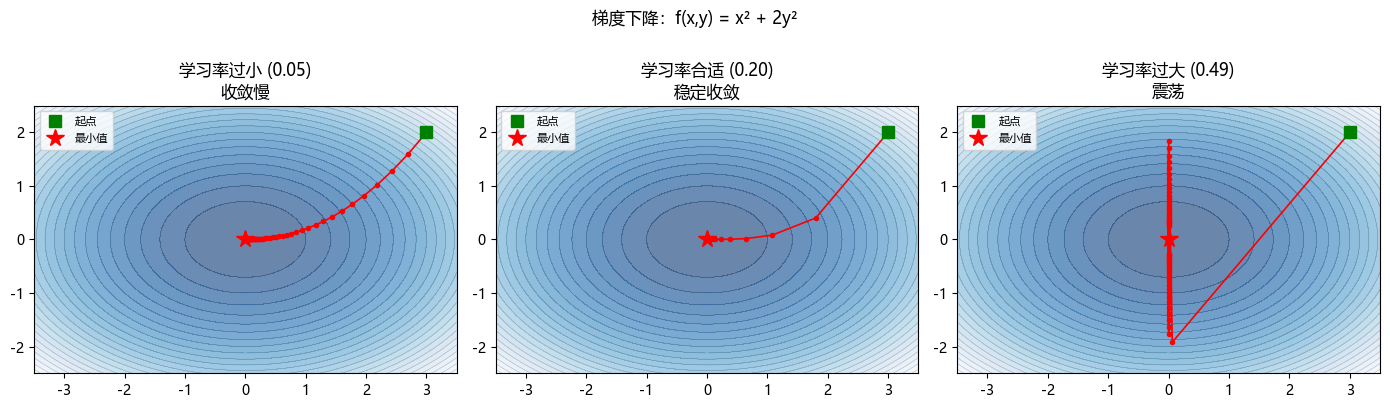

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ── 梯度下降：最小化 f(x,y) = x² + 2y² ──────────────────────
def gd(start, lr, n_steps=50):
    path = [start.copy()]
    x = start.copy()
    for _ in range(n_steps):
        grad = np.array([2*x[0], 4*x[1]])  # 解析梯度：∂f/∂x=2x, ∂f/∂y=4y
        x = x - lr * grad
        path.append(x.copy())
    return np.array(path)

start = np.array([3.0, 2.0])

x_r = np.linspace(-3.5, 3.5, 200)
y_r = np.linspace(-2.5, 2.5, 200)
X_g, Y_g = np.meshgrid(x_r, y_r)
Z = X_g**2 + 2 * Y_g**2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [(0.05, '学习率过小 (0.05)\n收敛慢'),
           (0.20, '学习率合适 (0.20)\n稳定收敛'),
           (0.49, '学习率过大 (0.49)\n震荡')]

for ax, (lr, title) in zip(axes, configs):
    path = gd(start, lr)
    ax.contourf(X_g, Y_g, Z, levels=25, cmap='Blues_r', alpha=0.6)
    ax.contour(X_g, Y_g, Z, levels=25, colors='gray', linewidths=0.4, alpha=0.5)
    ax.plot(path[:, 0], path[:, 1], 'o-', color='red', ms=3, lw=1.2)
    ax.plot(start[0], start[1], 'gs', ms=9, zorder=5, label='起点')
    ax.plot(0, 0, 'r*', ms=13, zorder=5, label='最小值')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('梯度下降：f(x,y) = x² + 2y²', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

=== 链式法则：单神经元反向传播 ===
前向: a = 0.5*2.0 + -1.0 = 0.0
前向: z = sigmoid(0.0) = 0.5000
反向: dL/dw = dL/dz · sigmoid'(a) · x = 0.5000
反向: dL/db = dL/dz · sigmoid'(a) · 1 = 0.2500


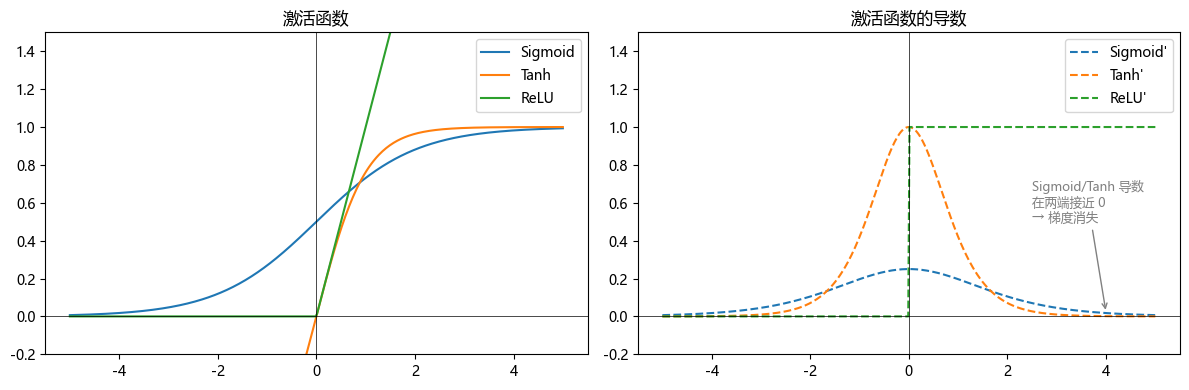

ReLU 导数恒为 0 或 1，有效缓解深层网络的梯度消失问题。


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── 链式法则：单神经元反向传播 ────────────────────────────────
# 计算图: z = sigmoid(w*x + b), 对 w, b 求导

sigmoid     = lambda a: 1 / (1 + np.exp(-a))
sigmoid_grad = lambda a: sigmoid(a) * (1 - sigmoid(a))

x, w, b = 2.0, 0.5, -1.0
a = w * x + b
z = sigmoid(a)

dL_dz = 1.0                         # 假设损失对 z 的梯度为 1
dL_dw = dL_dz * sigmoid_grad(a) * x  # 链式法则
dL_db = dL_dz * sigmoid_grad(a) * 1

print('=== 链式法则：单神经元反向传播 ===')
print(f'前向: a = {w}*{x} + {b} = {a}')
print(f'前向: z = sigmoid({a}) = {z:.4f}')
print(f'反向: dL/dw = dL/dz · sigmoid\'(a) · x = {dL_dw:.4f}')
print(f'反向: dL/db = dL/dz · sigmoid\'(a) · 1 = {dL_db:.4f}')

# ── 激活函数及其导数（梯度消失直觉） ─────────────────────────
x_vals = np.linspace(-5, 5, 400)

acts = {
    'Sigmoid': (lambda x: 1/(1+np.exp(-x)),
                lambda x: (s := 1/(1+np.exp(-x)), s*(1-s))[1]),
    'Tanh':    (np.tanh,
                lambda x: 1 - np.tanh(x)**2),
    'ReLU':    (lambda x: np.maximum(0, x),
                lambda x: (x > 0).astype(float)),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (f, df) in acts.items():
    axes[0].plot(x_vals, f(x_vals), label=name)
    axes[1].plot(x_vals, df(x_vals), label=f"{name}'", linestyle='--')

for ax, title in zip(axes, ['激活函数', '激活函数的导数']):
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(-0.2, 1.5)

axes[1].annotate('Sigmoid/Tanh 导数\n在两端接近 0\n→ 梯度消失',
                 xy=(4, 0.02), xytext=(2.5, 0.5),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=9, color='gray')
plt.tight_layout()
plt.show()
print('ReLU 导数恒为 0 或 1，有效缓解深层网络的梯度消失问题。')